## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [6]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [7]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1Sp74YgcCWMykUZ5ZGgllfE-hxb6VzPRJ', 'filename':'dataset1.csv'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1UkbiqUGRhyRhUPCMYCTkAhGzPF2QOdYM', 'filename':'dataset2.csv'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1cFazIGXBgy7HeQLAC3ClZUK4dRVbxOZJ', 'filename':'dataset3.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  33%|███▎      | 1/3 [00:00<00:01,  1.01it/s]

Successfully downloaded: dataset1.csv



Overall Download Progress:  67%|██████▋   | 2/3 [00:02<00:01,  1.42s/it]      

Successfully downloaded: dataset2.csv



Overall Download Progress: 100%|██████████| 3/3 [00:04<00:00,  1.48s/it]      


Successfully downloaded: dataset3.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [8]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from data/00-raw/
policy_data = pd.read_csv("data/00-raw/dataset1.csv")

# View the dataset
policy_data.head()

,Unnamed: 0,"Included in at least 1 state law definition of ""Tobacco Product""",Excise or Special Tax (non-sales tax),Product Packaging,Youth Access / Other Retail Restrictions,Retail License / Permit Required,Smoke-Free Restrictions,Age,Military Exception Age
0,Alabama,No,NaN,Yes,Yes,Yes,Yes,21,NaN
1,Alaska,No,NaN,NaN,Yes,Yes,Yes,19,NaN
2,Arizona,No,NaN,NaN,Yes,No,Yes,18,NaN
3,Arkansas,No,NaN,Yes,Yes,Yes,Yes,21,19.0
4,California,Yes,Yes,Yes,Yes,Yes,Yes,21,18.0


In [9]:
# Check the columns of the dataset
print(policy_data.columns)

# Check for multiple values in a single cell (nested data)
nested_found = False
for col in policy_data.columns:
    sample = policy_data[col].iloc[0]
    if isinstance(sample, (list, dict)):
        print(f'Column {col} may not be tidy; contains nested data.')
        nested_found = True

if not nested_found:
    print("\nAll columns passed: no nested data found. Dataset appears tidy.")

Index(['Unnamed: 0',
       'Included in at least 1 state law definition of "Tobacco Product"',
       'Excise or Special Tax (non-sales tax)', 'Product Packaging',
       'Youth Access / Other Retail Restrictions',
       'Retail License / Permit Required', 'Smoke-Free Restrictions', 'Age',
       'Military Exception Age'],
      dtype='object')

All columns passed: no nested data found. Dataset appears tidy.


In [10]:
# Demonstrate the size of the dataset
policy_data.shape

(51, 9)

In [11]:
# Rename columns to be concise
policy_data.rename(columns={"Unnamed: 0": "State", 'Included in at least 1 state law definition of "Tobacco Product"': "Included in State Definition",
                           "Excise or Special Tax (non-sales tax)": "Tax", "Youth Access / Other Retail Restrictions": "Youth Restrictions",
                           "Retail License / Permit Required": "Permit Required"}, inplace=True)

In [12]:
# Check how much data is missing
print(f"Number of rows with missing data: {policy_data.isna().any(axis=1).sum()}\n")

# Check where the data is missing
print(f"Missing data per column:\n{policy_data.isna().sum()}")

Number of rows with missing data: 47

Missing data per column:
State                            0
Included in State Definition     0
Tax                             16
Product Packaging               18
Youth Restrictions               0
Permit Required                  0
Smoke-Free Restrictions          2
Age                              0
Military Exception Age          45
dtype: int64


In [13]:
# Examine columns with missing values
print(f"Unique values in Tax column: {policy_data['Tax'].unique()}")
print(f"Unique values in Product Packaging column: {policy_data['Product Packaging'].unique()}")
print(f"Unique values in Smoke-Free Restrictions column: {policy_data['Smoke-Free Restrictions'].unique()}")
print(f"Unique values in Military Exception Age column: {policy_data['Military Exception Age'].unique()}")

Unique values in Tax column: [nan 'Yes' 'No']
Unique values in Product Packaging column: ['Yes' nan]
Unique values in Smoke-Free Restrictions column: ['Yes' 'No' nan 'Yes ']
Unique values in Military Exception Age column: [nan 19. 18.]


In [14]:
# In the binary Yes/No columns, fill missing data with unknown. In numerical columns, fill missing data with -1.
policy_data = policy_data.fillna({
    'Tax': 'Unk',
    'Product Packaging': 'Unk',
    'Smoke-Free Restrictions': 'Unk',
    'Military Exception Age': -1})

# Check missingness
print(f"Missing data per column:\n{policy_data.isna().sum()}")

Missing data per column:
State                           0
Included in State Definition    0
Tax                             0
Product Packaging               0
Youth Restrictions              0
Permit Required                 0
Smoke-Free Restrictions         0
Age                             0
Military Exception Age          0
dtype: int64


In [15]:
# When looking at unique values in each column, we noticed that Smoke-Free Restrictions looked interesting
print(f"Unique values in Smoke-Free Restrictions column: {policy_data['Smoke-Free Restrictions'].unique()}")

Unique values in Smoke-Free Restrictions column: ['Yes' 'No' 'Unk' 'Yes ']


In [16]:
# Change Smoke-Free Restrictions column to remove whitespace
policy_data['Smoke-Free Restrictions'] = policy_data['Smoke-Free Restrictions'].str.strip()

# Verify that we now only have Yes, No, and Unk values
print(f"Unique values in Smoke-Free Restrictions column: {policy_data['Smoke-Free Restrictions'].unique()}")

Unique values in Smoke-Free Restrictions column: ['Yes' 'No' 'Unk']


In [17]:
# This dataset should contain one row per US state. Why are there 51 rows?
policy_data['State']

0                  Alabama
1                   Alaska
2                  Arizona
3                 Arkansas
4               California
5                 Colorado
6              Connecticut
7                 Delaware
8     District of Columbia
9                  Florida
10                 Georgia
11                  Hawaii
12                   Idaho
13                Illinois
14                 Indiana
15                    Iowa
16                  Kansas
17                Kentucky
18               Louisiana
19                   Maine
20                Maryland
21           Massachusetts
22                Michigan
23               Minnesota
24             Mississippi
25                Missouri
26                 Montana
27                Nebraska
28                  Nevada
29           New Hampshire
30              New Jersey
31              New Mexico
32                New York
33          North Carolina
34            North Dakota
35                    Ohio
36                Oklahoma
3

In [18]:
# The dataset contains all 50 states as well as the District of Columbia. Remove that row.
policy_data = policy_data.drop(index=8)

# Reset index
policy_data.reset_index(inplace=True, drop=True)

# Look at shape of data
policy_data.shape

(50, 9)

In [19]:
# To make it easy to combine this dataset with our other datasets, we need a column with the abbreviation of each state
# Create a dictionary to map state names to abbreviations
state_dict = {"Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO", "Connecticut": "CT",
    "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH",
    "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"}

# Create a new column in the DataFrame with state abbreviations
policy_data['StateAbbr'] = policy_data['State'].map(state_dict)

In [20]:
# Check for duplicate rows
print(f"Number of duplicate rows: {policy_data.duplicated().sum()}")

# Check the final shape of the dataset
print(f"Dataset shape: {policy_data.shape}")

# Save final wrangled data
policy_data.to_csv("data/02-processed/policy_data_cleaned.csv", index=False)

Number of duplicate rows: 0
Dataset shape: (50, 10)


This graph shows how many states don't have a military exception for smoking/vaping, and how many do. Looking at the graph, most states, around 45, dont have military exceptions, meaning those under the legal age of 21, cannot purchace or smoke vapes or cigarettes. The remaining 5 states however, do have military exceptions for those 18 or 19 years old, allowing them to purchase tobacco or nicotine products.

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
# Load the dataset from data/00-raw/
yts_data = pd.read_csv("data/00-raw/dataset2.csv")

# View the dataset
yts_data.head()

In [ ]:
# Check the columns of the dataset
print(yts_data.columns)

# Check for multiple values in a single cell (nested data)
nested_found = False
for col in yts_data.columns:
    sample = yts_data[col].iloc[0]
    if isinstance(sample, (list, dict)):
        print(f'Column {col} may not be tidy; contains nested data.')
        nested_found = True

if not nested_found:
    print("\nAll columns passed: no nested data found. Dataset appears tidy.")

In [ ]:
# Demonstrate the size of the dataset
yts_data.shape

In [ ]:
# Check how much data is missing
print(f"Number of rows with missing data: {yts_data.isna().any(axis=1).sum()}\n")

# Check where the data is missing
print(f"Missing data per column:\n{yts_data.isna().sum()}")

In [ ]:
# Examine columns with lots of missing values
print(f"Unique values in Data_Value_Footnote column: {yts_data['Data_Value_Footnote'].unique()}\n")
print(f"Unique values in Data_Value_Footnote_Symbol column: {yts_data['Data_Value_Footnote_Symbol'].unique()}\n")

In [ ]:
# Looks like in this case the presence of a footnote and footnote symbol indicates suppressed data
# To verify this claim, create a DataFrame of only rows that have a footnote
footnote_rows = yts_data[yts_data['Data_Value_Footnote'] == 'Data in these cells have been suppressed because of a small sample size']

# Check the shape of the new DataFrame
print(f"Shape of footnote_rows DataFrame: {footnote_rows.shape}\n")

# Check for missingness in the new DataFrame
# This shows that every row that contains a footnote has missing values in 6 other columns
print(f"Missing data per column in footnote_rows DataFrame:\n{footnote_rows.isna().sum()}")

In [ ]:
# Now, in our original DataFrame, we know that we can safely drop rows that have a footnote, since those rows contain missing data
yts_data = yts_data[yts_data['Data_Value_Footnote'] != 'Data in these cells have been suppressed because of a small sample size']

# We can also drop the Data_Value_Footnote and Data_Value_Footnote_Symbol columns because they no longer contain meaningful information
yts_data.drop(columns=['Data_Value_Footnote', 'Data_Value_Footnote_Symbol'], inplace=True)

# Save interim progress
yts_data.to_csv("data/01-interim/yts_data_removed_footnotes.csv", index=False)

In [ ]:
# Check for missingness again
yts_data.isna().sum()

In [ ]:
# Isolate the rows that have missing values in the Response column
missing_response = yts_data[yts_data['Response'].isna()]

# Examine TopicDesc column
print(f"Unique values in TopicDesc column for all data: {yts_data['TopicDesc'].unique()}\n")
print(f"Unique values in TopicDesc column among rows with missing data in Response: {missing_response['TopicDesc'].unique()}")

In [ ]:
# All of the rows with missing data in the Response column correspond with the string 'Cessation (Youth)' in the TopicDesc column
# Fill missing values in the Response column with a meaningful placeholder
yts_data['Response'] = yts_data['Response'].fillna('Quit')

# Drop all other rows with missing values
yts_data = yts_data.dropna()

# Examine missingness
print(f"{yts_data.isna().sum()}")

In [ ]:
# Check for duplicate rows
print(f"Number of duplicate rows: {yts_data.duplicated().sum()}")

# Drop ID columns that are not relevant to our analysis
yts_data = yts_data.drop(['TopicTypeId', 'TopicId', 'MeasureId', 'StratificationID1', 'StratificationID2', 'StratificationID3',
                         'StratificationID4', 'SubMeasureID', 'DisplayOrder'], axis=1)

# Rename LocationAbbr column to make it easier to combine with other datasets
yts_data.rename(columns={'LocationAbbr': 'StateAbbr'}, inplace=True)

# Check the final shape of the dataset
print(f"Dataset shape: {yts_data.shape}")

# Save final wrangled data
yts_data.to_csv("data/02-processed/yts_data_cleaned.csv", index=False)

In [ ]:
# Summary statistics for numerical columns
numeric_cols = ['Data_Value', 'Data_Value_Std_Err', 'Low_Confidence_Limit', 'High_Confidence_Limit', 'Sample_Size']
yts_data[numeric_cols].describe()

### Dataset #3
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE

# Load the dataset from data/00-raw/
tweet_data = pd.read_csv("data/00-raw/dataset3.csv", index_col=0)

# View the dataset
tweet_data.head()

In [ ]:
# Check the columns of the dataset
print(tweet_data.columns)

# Check for multiple values in a single cell (nested data)
nested_found = False
for col in tweet_data.columns:
    sample = tweet_data[col].iloc[0]
    if isinstance(sample, (list, dict)):
        print(f'Column {col} may not be tidy; contains nested data.')
        nested_found = True

if not nested_found:
    print("\nAll columns passed: no nested data found. Dataset appears tidy.")

In [ ]:
# Demonstrate the size of the dataset
tweet_data.shape

In [ ]:
# Check how much data is missing
print(f"Number of rows with missing data: {tweet_data.isna().any(axis=1).sum()}\n")

# Check where the data is missing
print(f"Missing data per column:\n{tweet_data.isna().sum()}")

In [ ]:
# Looks like every single row has missing data in the TweetCoordinate column. Let's remove that column.
tweet_data.drop('TweetCoordinate', axis=1, inplace=True)

In [ ]:
# Now lets investigate the data that has missing values in TweetState
missing_state_data = tweet_data[tweet_data['TweetState'].isna()]
missing_state_data

In [ ]:
# There doesn't appear to be a pattern among the data that is missing TweetState, so we will just drop rows that have missing values
tweet_data = tweet_data.dropna()

In [ ]:
# Now, let's look more closely at the TweetState column
print(f"Unique values in the TweetState column:\n{tweet_data['TweetState'].unique()}")

In [ ]:
# For our analysis, we only want to include tweets that were posted in the US
# Create a list of all US state abbreviations
states_list = ["AK", "AL", "AR", "AZ", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "IA",
    "ID", "IL", "IN", "KS", "KY", "LA", "MA", "MD", "ME", "MI", "MN", "MO",
    "MS", "MT", "NC", "ND", "NE", "NH", "NJ", "NM", "NV", "NY", "OH", "OK",
    "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VA", "VT", "WA", "WI",
    "WV", "WY"]

# Only keep rows where TweetState is a US state
tweet_data = tweet_data[tweet_data['TweetState'].isin(states_list)]

# Check unique values in TweetState column to verify that they are all US states
print(f"Unique values in the TweetState column:\n{tweet_data['TweetState'].unique()}\n")

# Check that there are 50 unique values in the TweetState column
print(f"Number of unique values in the TweetState column:\n{tweet_data['TweetState'].nunique()}")

In [ ]:
# Check for duplicate rows
print(f"Number of duplicate rows: {tweet_data.duplicated().sum()}")

# Check the final shape of the dataset
print(f"Dataset shape: {tweet_data.shape}")

# Rename TweetState column to StateAbbr to make it easier to combine with other datasets
tweet_data.rename(columns={'TweetState': 'StateAbbr'}, inplace=True)

# Save final wrangled data
tweet_data.to_csv("data/02-processed/tweet_data_cleaned.csv", index=False)

In [ ]:
# Visualize distribution of sentiment scores
# The plot shows that there are many tweets with either positive or negative sentiment, meaning that sentiment varies within the dataset
sns.countplot(x='VADER_sentiment_class', data=tweet_data)
plt.title("Distribution of Tweet Sentiment")
plt.show()

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [17]:
## YOUR CODE HERE
policy_eda_data = pd.read_csv("data/02-processed/policy_data_cleaned.csv")

/tmp/ipykernel_395/2549284878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Has Military Exception', palette = ['pink','#d1ffd0'],data=policy_data)


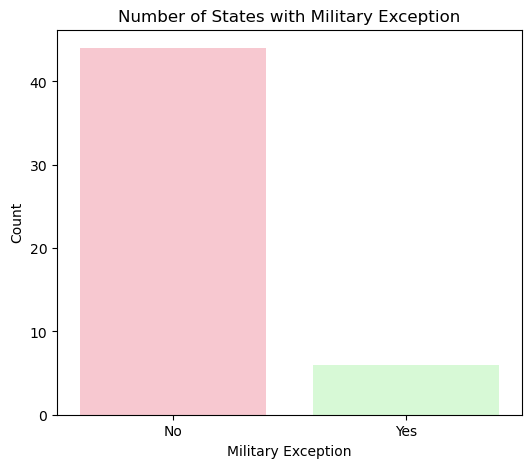

In [35]:
policy_data['Has Military Exception'] = policy_data['Military Exception Age'].apply(lambda x: 'Yes' if x > 0 else 'No')

plt.figure(figsize=(6, 5))
sns.countplot(x='Has Military Exception', palette = ['pink','#d1ffd0'],data=policy_data)
plt.title('Number of States with Military Exception')
plt.xlabel('Military Exception')
plt.ylabel('Count')
plt.show()

#### Section 2 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [1]:
## YOUR CODE HERE
yts_eda_data = pd.read_csv("data/02-processed/yts_data_cleaned.csv")

#### Section 3 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
tweet_eda_data = pd.read_csv("data/02-processed/tweet_data_cleaned.csv")

#### Section 4 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them